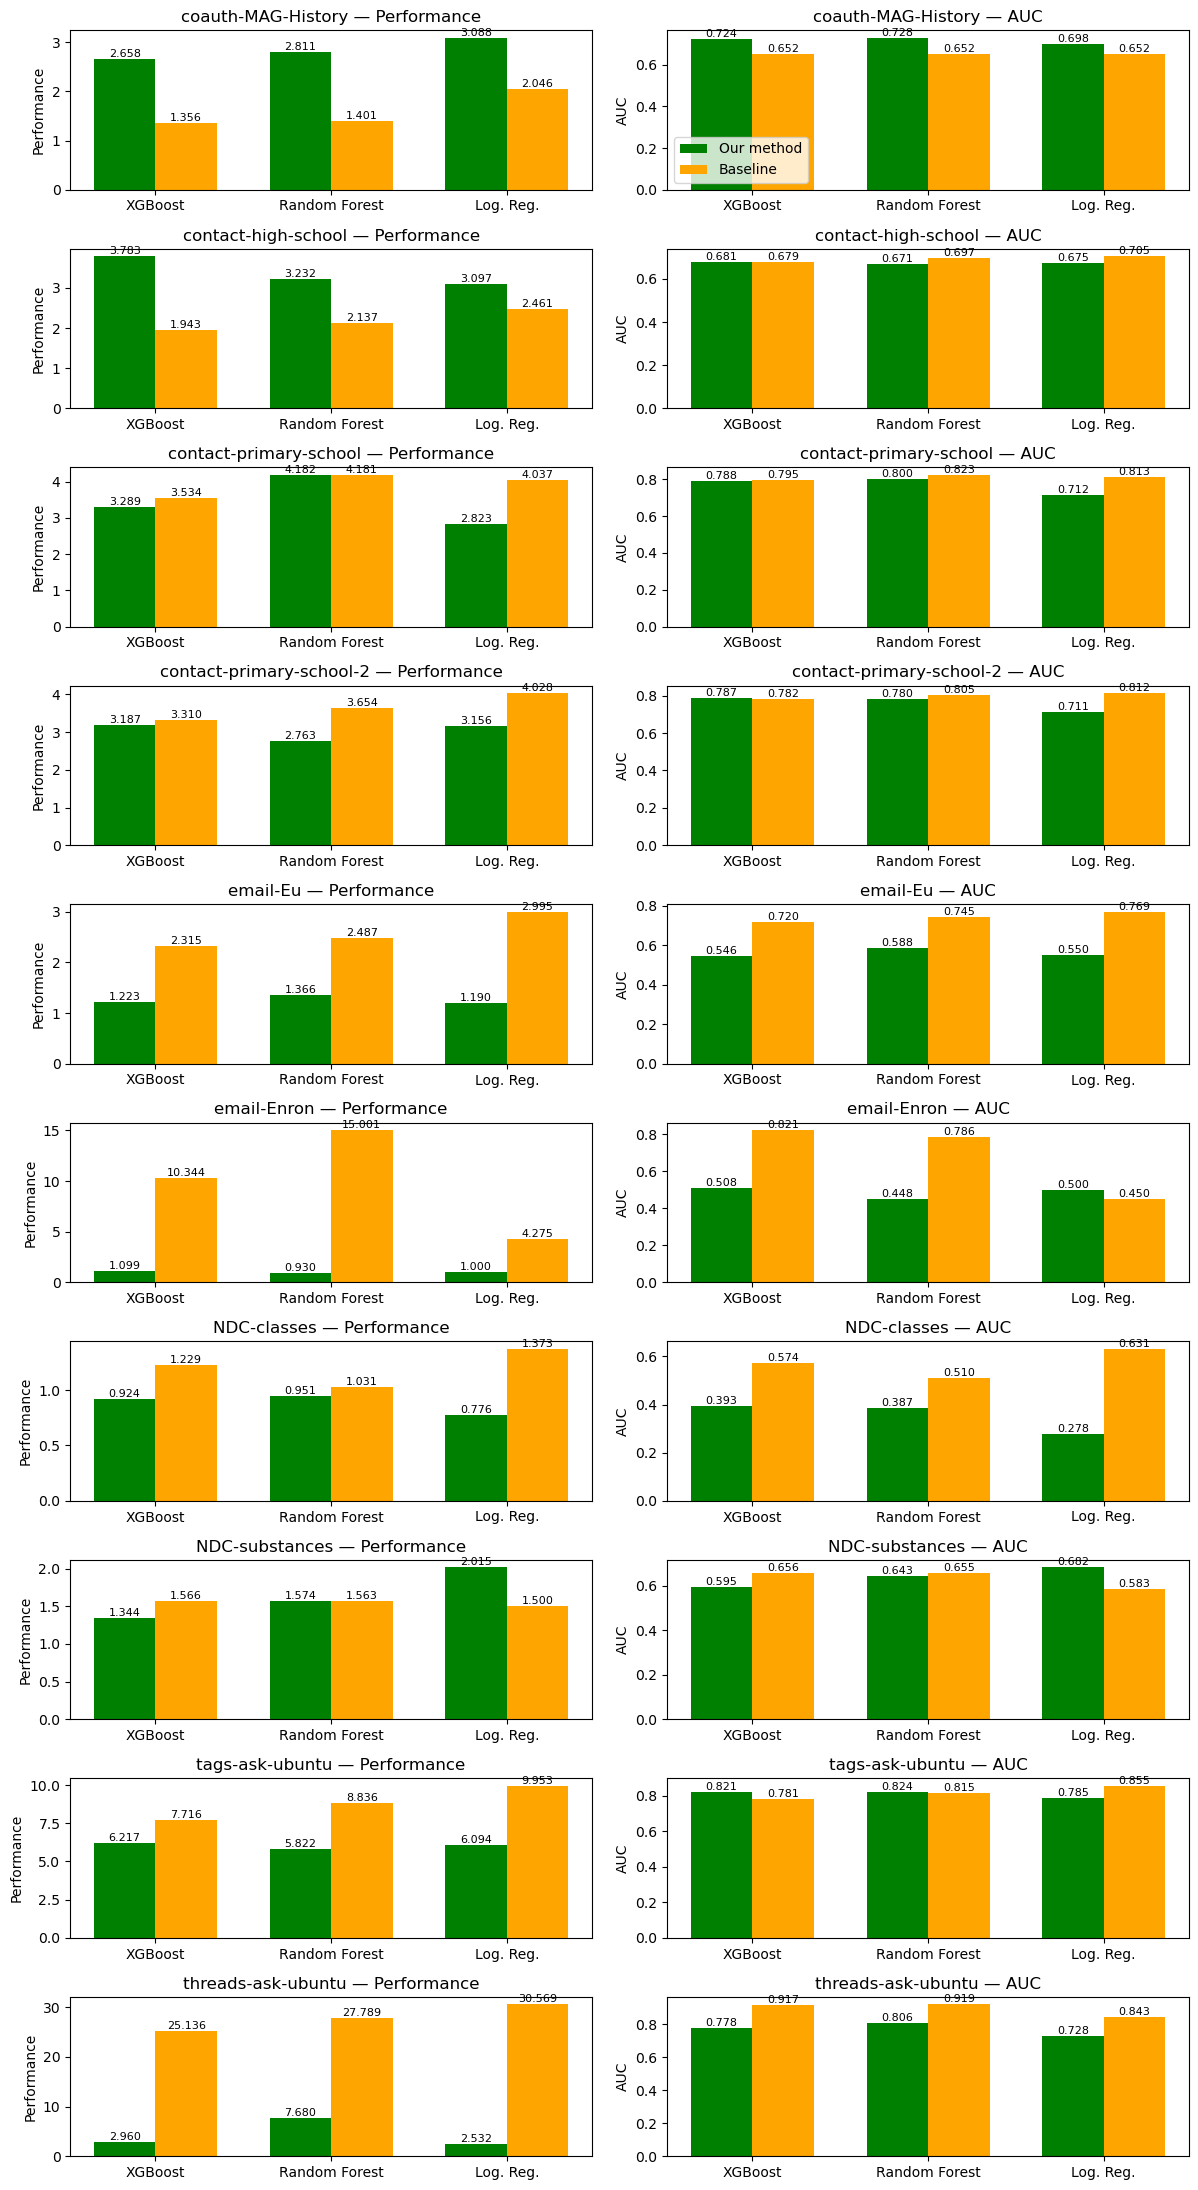

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Datasets and methods
datasets = [
    "coauth-MAG-History",
    "contact-high-school",
    "contact-primary-school",
    "contact-primary-school-2",
    "email-Eu",
    "email-Enron",
    "NDC-classes",
    "NDC-substances",
    "tags-ask-ubuntu",
    "threads-ask-ubuntu"
]
methods = ["xgb", "rf", "lr"]
method_labels = ["XGBoost", "Random Forest", "Log. Reg."]
metrics = ["performance", "auc"]
metric_labels = {"performance": "Performance", "auc": "AUC"}

# Base paths
our_base = Path("results/time")
baseline_base = Path("baseline/results_baseline/time")

# Function to read a single CSV and return a dict with values
def read_metrics(path):
    df = pd.read_csv(path)
    return df.iloc[0].to_dict()  # single row

# Collect data
data = []
for dataset in datasets:
    for method in methods:
        our_path = our_base / dataset / "metrics" / f"test_{method}.csv"
        base_path = baseline_base / dataset / "metrics" / f"test_{method}.csv"

        our_metrics = read_metrics(our_path)
        base_metrics = read_metrics(base_path)

        data.append({
            "dataset": dataset,
            "method": method,
            "type": "our",
            "performance": our_metrics["performance"],
            "auc": our_metrics["auc"]
        })
        data.append({
            "dataset": dataset,
            "method": method,
            "type": "baseline",
            "performance": base_metrics["performance"],
            "auc": base_metrics["auc"]
        })

# Convert to DataFrame
df = pd.DataFrame(data)

# --- Plotting ---
fig, axes = plt.subplots(nrows=10, ncols=2, figsize=(12, 22))
fig.subplots_adjust(hspace=0.4, wspace=0.25)

for i, dataset in enumerate(datasets):
    for j, metric in enumerate(metrics):
        ax = axes[i, j]
        subset = df[df["dataset"] == dataset]

        x = range(len(methods))
        width = 0.35

        our_vals = [subset[(subset["method"] == m) & (subset["type"] == "our")][metric].values[0] for m in methods]
        base_vals = [subset[(subset["method"] == m) & (subset["type"] == "baseline")][metric].values[0] for m in methods]

        bars_our = ax.bar([p - width/2 for p in x], our_vals, width, label="Our method", color="green")
        bars_base = ax.bar([p + width/2 for p in x], base_vals, width, label="Baseline", color="orange")

        # Add numbers above bars
        for bar in list(bars_our) + list(bars_base):
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.3f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

        ax.set_title(f"{dataset} — {metric_labels[metric]}")
        ax.set_xticks(x)
        ax.set_xticklabels(method_labels)
        ax.set_ylabel(metric_labels[metric])
        if i == 0 and j == 1:
            ax.legend()

plt.tight_layout()
plt.show()
